# Training

In [1]:
# Imports for Training #

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
import tensorflow as tf
import keras.backend as K
from tensorflow.keras.layers import Input, Conv2D, ReLU, MaxPool2D, BatchNormalization, Concatenate, Add
from tensorflow.keras.models import Model
from qkeras.qlayers import QConv2D, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu

I0000 00:00:1776978966.007313    5599 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776978966.177827    5599 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776978966.851877    5599 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Constants #

IMAGE_X = 256
IMAGE_Y = 256

GAUSSIAN_X = 48
GAUSSIAN_Y = 48

SCALE_FACTOR = 8

LABEL_X = IMAGE_X // SCALE_FACTOR
LABEL_Y = IMAGE_Y // SCALE_FACTOR

MIN_NUM_GAUSSIANS = 2
MAX_NUM_GAUSSIANS = 4

MIN_STD_X = 5
MAX_STD_X = 11

MIN_STD_Y = 5
MAX_STD_Y = 11

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.2
MAX_INTENSITY = 0.8

THRESHOLD = 0.5

In [3]:
# Util Functions #

def img_gen(VERBOSE: bool = False) -> tuple:

    img = np.zeros(shape=(IMAGE_Y, IMAGE_X, 1))
    label = np.zeros(shape=(LABEL_Y, LABEL_X, 1))
    params = []

    num_gaussians = np.random.randint(low=MIN_NUM_GAUSSIANS, high=MAX_NUM_GAUSSIANS)
    for gaussian in range(num_gaussians):

        # Randomize params
        center_x = np.random.randint(low=0 + GAUSSIAN_X // 2, high=IMAGE_X - GAUSSIAN_X // 2)
        center_y = np.random.randint(low=0 + GAUSSIAN_Y // 2, high=IMAGE_Y - GAUSSIAN_Y // 2)

        std_x = np.random.randint(low=MIN_STD_X, high=MAX_STD_X)
        std_y = np.random.randint(low=MIN_STD_Y, high=MAX_STD_Y)
        theta = np.random.randint(low=MIN_THETA, high=MAX_THETA)
        
        intensity = np.random.uniform(low=MIN_INTENSITY, high=MAX_INTENSITY)
        
        # Generate Gaussian
        params.append((center_x, center_y, std_x, std_y, theta, intensity))
        gaussian = gaussian_gen(center_x, center_y, std_x, std_y, theta)

        # Add Gaussian to img
        img += intensity * gaussian

    label = make_soft_label(params, LABEL_Y, LABEL_X, SCALE_FACTOR, sigma=0.75)
    
    # Convert to 8 bit int
    label = (label * 255).astype(np.uint8)
    img = (img * 255).astype(np.uint8)

    # DEBUG
    if VERBOSE:
        # print(f"[Image Shape]: {str(img.shape)}")
        # print(f"[Label Shape]: {str(label.shape)}")
        print(f"[Target Gaussians #]: {str(num_gaussians)}")
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )

    return (img, label, params)

def gaussian_gen(center_x: int, center_y: int, std_x: int, std_y: int, theta: float) -> np.ndarray:
    
    X = np.arange(0, IMAGE_X, 1)
    Y = np.arange(0, IMAGE_Y, 1)
    X, Y = np.meshgrid(X, Y)

    cos_theta_sqrd = np.power(np.cos(theta),2)
    sin_theta_sqrd = np.power(np.sin(theta),2)
    sin_cos_theta = np.sin(theta) * np.cos(theta)

    std_x_sqrd = np.power(std_x, 2)
    std_y_sqrd = np.power(std_y, 2)

    a = (cos_theta_sqrd) / (2 * std_x_sqrd) + (sin_theta_sqrd) / (2 * std_y_sqrd)
    b = -1 * (sin_cos_theta) / (2 * std_x_sqrd) + (sin_cos_theta) / (2 * std_y_sqrd)
    c = (sin_theta_sqrd) / (2 * std_x_sqrd) + (cos_theta_sqrd) / (2 * std_y_sqrd)

    gaussian = np.exp(-(a * (X - center_x)**2 + 2*b * (X - center_x) * (Y - center_y) + c * (Y - center_y)**2))

    return np.expand_dims(gaussian, -1)

def make_soft_label(params, label_h, label_w, scale_factor, sigma=0.75):
    yy, xx = np.meshgrid(np.arange(label_h), np.arange(label_w), indexing='ij')
    label = np.zeros((label_h, label_w), dtype=np.float32)
    for center_x, center_y, std_x, std_y, theta, intensity in params:
        gx = center_x / scale_factor
        gy = center_y / scale_factor
        bump = np.exp(-((xx - gx)**2 + (yy - gy)**2) / (2 * sigma**2))
        label = np.maximum(label, bump)
    return label[..., None]

def img_visualization_one(img: np.ndarray, label: np.ndarray, params: list = None, threshold: int = THRESHOLD) -> None:
    
    rgb_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Coords of Gaussians:
    for x in range(LABEL_X):
        for y in range(LABEL_Y):
            if label[y, x,] >= threshold:
                
                top_left = (x * SCALE_FACTOR - GAUSSIAN_X // 2, y * SCALE_FACTOR - GAUSSIAN_Y // 2)
                bottom_right = (x * SCALE_FACTOR + GAUSSIAN_X // 2, y * SCALE_FACTOR + GAUSSIAN_Y // 2)
                color = (0, 200, 200)
                thickness = 2
                
                cv2.rectangle(rgb_image, top_left, bottom_right, color, thickness)

    if params != None:
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )
    
    plt.imshow(rgb_image)

def img_visualization_two(img: np.ndarray, label: np.ndarray, params: list = None) -> None:
    
    if params != None:
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    
    plt.subplot(1, 2, 2)
    plt.imshow(label, cmap='gray')

[(c_x, c_y)]: (90 , 180) [(s_x, s_y)]: (9  , 10 ) [Theta]: 0.00 [I]: 0.78 
[(c_x, c_y)]: (79 , 156) [(s_x, s_y)]: (7  , 6  ) [Theta]: 2.00 [I]: 0.26 
[(c_x, c_y)]: (39 , 132) [(s_x, s_y)]: (9  , 7  ) [Theta]: 0.00 [I]: 0.45 


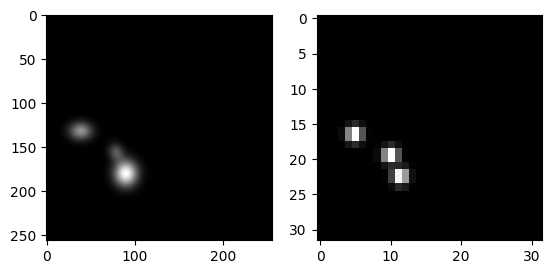

In [4]:
# Test Util Functions #

img, label, params = img_gen()
img_visualization_two(img, label, params)

In [5]:
# Generate Training Dataset #
SAMPLE_COUNT = 1000

img_arr = []
label_arr = []

def process_image():
    img, label, _ = img_gen()
    return img, label

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(SAMPLE_COUNT)]
    for future in tqdm(as_completed(futures), total=SAMPLE_COUNT):
        img, label = future.result()
        img_arr.append((img.astype(np.float32)) / 256.0)         # Normalize values to [0, 1)
        label_arr.append((label.astype(np.float32)) / 256.0)     # Normalize values to [0, 1)

img_arr = np.array(img_arr).astype(np.float32)
label_arr = np.array(label_arr).astype(np.float32)

print(f'[Images Shape]: {img_arr.shape}')
print(f'[Labels Shape]: {label_arr.shape}')

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:00<00:00, 1791.54it/s]

[Images Shape]: (1000, 256, 256, 1)
[Labels Shape]: (1000, 32, 32, 1)


In [6]:
# Create Validation Dataset for Training #
VAL_COUNT = 100

img_arr_val_t = []
label_arr_val_t = []

def process_image():
    img, label, _ = img_gen()
    return img, label

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(VAL_COUNT)]
    for future in tqdm(as_completed(futures), total=VAL_COUNT):
        img, label = future.result()
        img_arr_val_t.append((img.astype(np.float32)) / 256.0)        # Normalize values to [0, 1)
        label_arr_val_t.append((label.astype(np.float32)) / 256.0)    # Normalize values to [0, 1)

img_arr_val_t = np.array(img_arr_val_t).astype(np.float32)
label_arr_val_t = np.array(label_arr_val_t).astype(np.float32)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:00<00:00, 2046.53it/s]


In [7]:
# Convert Data to TF Dataset #
BATCH_SIZE = 25

dataset = tf.data.Dataset.from_tensor_slices((img_arr, label_arr))
dataset = dataset.shuffle(SAMPLE_COUNT, reshuffle_each_iteration=True)
dataset = dataset.batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((img_arr_val_t, label_arr_val_t))
val_dataset = val_dataset.shuffle(VAL_COUNT, reshuffle_each_iteration=True)
val_dataset = val_dataset.batch(BATCH_SIZE)

W0000 00:00:1776978980.631318    5599 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [8]:
# Qkeras Model Architecture #
TOTAL_BITS = 10
INTEGER_BITS = 2


w_quant = quantized_bits(TOTAL_BITS, INTEGER_BITS, 0)
a_quant = quantized_bits(TOTAL_BITS, INTEGER_BITS, 1)
relu_quant = quantized_relu(TOTAL_BITS, INTEGER_BITS)

input_layer = Input(shape=(IMAGE_X, IMAGE_Y, 1))

x = QConv2D(4, 3, strides=2, padding='same', use_bias=False, kernel_quantizer=w_quant, name="qconv2d_1_1")(input_layer)
x = BatchNormalization(name="b_1_1")(x)
x = QActivation(relu_quant, name="qact_1_1")(x)
y = QConv2D(4, 3, padding='same', use_bias=False, kernel_quantizer=w_quant, name="qconv2d_1_2")(x)
y = BatchNormalization(name="b_1_2")(y)
x = Add(name="add_1")([x, y])
x = QActivation(relu_quant, name="qact_1_2")(x)

x = QConv2D(6, 3, strides=2, padding='same', use_bias=False, kernel_quantizer=w_quant, name="qconv2d_2_1")(x)
x = BatchNormalization(name="b_2_1")(x)
x = QActivation(relu_quant, name="qact_2_1")(x)
y = QConv2D(6, 3, padding='same', use_bias=False, kernel_quantizer=w_quant, name="qconv2d_2_2")(x)
y = BatchNormalization(name="b_2_2")(y)
x = Add(name="add_2")([x, y])
x = QActivation(relu_quant, name="qact_2_2")(x)

x = QConv2D(8, 3, strides=2, padding='same', use_bias=False, kernel_quantizer=w_quant, name="qconv2d_3_1")(x)
x = BatchNormalization(name="b_3_1")(x)
x = QActivation(relu_quant, name="qact_3_1")(x)
y = QConv2D(8, 3, padding='same', use_bias=False, kernel_quantizer=w_quant, name="qconv2d_3_2")(x)
y = BatchNormalization(name="b_3_2")(y)
x = Add(name="add_3")([x, y])
x = QActivation(relu_quant, name="qact_3_2")(x)

x = Conv2D(8, 1, padding='same', activation='relu', name="conv2d_4")(x)

x_prob = Conv2D(1, 1, padding='same', activation='sigmoid', name="conv2d_5")(x)

baby_yolo_qk = Model(inputs=input_layer, outputs=x_prob, name='baby_yolo')

In [9]:
# Keras Model Architecture #
input_layer = Input(shape=(IMAGE_X, IMAGE_Y, 1))

x = Conv2D(4, 3, strides=2, padding='same', use_bias=False, name="conv2d_1_1")(input_layer)
x = BatchNormalization(name="b_1_1")(x)
x = ReLU(name="act_1_1")(x)
y = Conv2D(4, 3, padding='same', use_bias=False, name="conv2d_1_2")(x)
y = BatchNormalization(name="b_1_2")(y)
x = Add()([x, y])
x = ReLU(name="act_1_2")(x)

x = Conv2D(6, 3, strides=2, padding='same', use_bias=False, name="conv2d_2_1")(x)
x = BatchNormalization(name="b_2_1")(x)
x = ReLU(name="act_2_1")(x)
y = Conv2D(6, 3, padding='same', use_bias=False, name="conv2d_2_2")(x)
y = BatchNormalization(name="b_2_2")(y)
x = Add()([x, y])
x = ReLU(name="act_2_2")(x)

x = Conv2D(8, 3, strides=2, padding='same', use_bias=False, name="conv2d_3_1")(x)
x = BatchNormalization(name="b_3_1")(x)
x = ReLU(name="act_3_1")(x)
y = Conv2D(8, 3, padding='same', use_bias=False, name="conv2d_3_2")(x)
y = BatchNormalization(name="b_3_2")(y)
x = Add()([x, y])
x = ReLU(name="act_3_2")(x)

x = Conv2D(8, 1, padding='same', activation='relu', name="conv2d_4")(x)

x_prob = Conv2D(1, 1, padding='same', activation='sigmoid', name="conv2d_5")(x)

baby_yolo_tf = Model(inputs=input_layer, outputs=x_prob, name='baby_yolo')

In [10]:
# Tensorflow Functions #
POS_WEIGHT = 5.0
NEG_WEIGHT = 1.0

def loss_p(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    # Avoid log(0) inside BCE.
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    bce = -(y_true * tf.math.log(y_pred) +
            (1.0 - y_true) * tf.math.log(1.0 - y_pred))
    weights = y_true * POS_WEIGHT + (1.0 - y_true) * NEG_WEIGHT
    return tf.reduce_mean(weights * bce)

In [11]:
# Train or Load #
TRAIN_MODEL = False
LOAD_MODEL = True

MODEL_NAME = '[FOLO]_[Generated]_[256]_Q[10,2].keras'
NUM_EPOCHS = 100

EARLY_STOPPING_PATIENCE = 10
MIN_DELTA = 1e-4

if (TRAIN_MODEL and LOAD_MODEL):
    print("Are you sure you want to Train & Load ?")

elif (TRAIN_MODEL):
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.01,
        decay_steps=NUM_EPOCHS,
        decay_rate=0.9)
    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    baby_yolo_qk.compile(optimizer=adam_optimizer, loss=loss_p, run_eagerly=True)

    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None

    for epoch in range(NUM_EPOCHS):
        running_loss = 0.0
        
        for batch in tqdm(dataset):
            with tf.GradientTape() as tape:
                prediction = baby_yolo_qk(batch[0], training=True)
                loss = loss_p(batch[1], prediction)
            grads = tape.gradient(loss, baby_yolo_qk.trainable_variables)
            adam_optimizer.apply_gradients(zip(grads, baby_yolo_qk.trainable_variables))
            running_loss += loss.numpy()
            
        average_loss = running_loss / len(dataset)

        val_running_loss = 0.0
        for val_batch in val_dataset: 
            val_prediction = baby_yolo_qk(val_batch[0], training=False)
            val_loss = loss_p(batch[1], prediction)
            val_running_loss += val_loss.numpy()
        
        average_val_loss = val_running_loss / len(val_dataset)

        print(
            f"Epoch [{epoch+1}/{NUM_EPOCHS}], "
            f"Loss: {average_loss:.6f}, "
            f"Val Loss: {average_val_loss:.6f}"
        )

        if average_val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = average_val_loss
            patience_counter = 0
            best_weights = baby_yolo_qk.get_weights()
        else:
            patience_counter += 1
            print(f"No improvement for {patience_counter} epoch(s).")
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

    if best_weights is not None:
        baby_yolo_qk.set_weights(best_weights)
        print(f"Restored best model weights with val loss {best_val_loss:.6f}")

    # Translate Weights Qkeras to Keras #
    for q_layer, plain_layer in zip(baby_yolo_qk.layers, baby_yolo_tf.layers):
        if q_layer.weights and plain_layer.weights:
            plain_layer.set_weights(q_layer.get_weights())

elif (LOAD_MODEL):
    baby_yolo_tf = tf.keras.models.load_model(
        f'/home/pujan/Research/Rheed-FOLO/Models/{MODEL_NAME}',
        custom_objects={"loss_p": loss_p}
    )

baby_yolo_tf.summary()

Model: "baby_yolo"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1_1 (Conv2D) │ (None, 128, 128,  │         36 │ input_layer_1[0]… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_1_1               │ (None, 128, 128,  │         16 │ conv2d_1_1[0][0]  │
│ (BatchNormalizatio… │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ b_1_1[0][0]       │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1_2 (Conv2D) │ (None, 128, 128,  │        144 │ re_lu[0][0]       │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_1_2               │ (None, 128, 128,  │         16 │ conv2d_1_2[0][0]  │
│ (BatchNormalizatio… │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ re_lu[0][0],      │
│                     │ 4)                │            │ b_1_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ add[0][0]         │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2_1 (Conv2D) │ (None, 64, 64, 6) │        216 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_2_1               │ (None, 64, 64, 6) │         24 │ conv2d_2_1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64, 6) │          0 │ b_2_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2_2 (Conv2D) │ (None, 64, 64, 6) │        324 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_2_2               │ (None, 64, 64, 6) │         24 │ conv2d_2_2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64, 6) │          0 │ re_lu_2[0][0],    │
│                     │                   │            │ b_2_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64, 6) │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3_1 (Conv2D) │ (None, 32, 32, 8) │        432 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_3_1               │ (None, 32, 32, 8) │         32 │ conv2d_3_1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 32, 32, 8) │          0 │ b_3_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3_2 (Conv2D) │ (None, 32, 32, 8) │        576 │ re_lu_4[0][0]   

 Total params: 1,953 (7.63 KB)

 Trainable params: 1,881 (7.35 KB)

 Non-trainable params: 72 (288.00 B)

In [13]:
# Save Model #
SAVE_MODEL = False

if (SAVE_MODEL):
    baby_yolo_tf.save(f'/home/pujan/Research/Rheed-FOLO/Models/{MODEL_NAME}')


In [14]:
# Create Validation Dataset #
VAL_COUNT = 100

img_arr_val = []
label_arr_val = []

def process_image():
    img, label, _ = img_gen()
    return img, label

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(VAL_COUNT)]
    for future in tqdm(as_completed(futures), total=VAL_COUNT):
        img, label = future.result()
        img_arr_val.append((img.astype(np.float32)) / 256.0)        # Normalize values to [0, 1)
        label_arr_val.append((label.astype(np.float32)) / 256.0)    # Normalize values to [0, 1)

img_arr_val = np.array(img_arr_val).astype(np.float32)
label_arr_val = np.array(label_arr_val).astype(np.float32)

predictions_tf = baby_yolo_tf.predict(img_arr_val)

print(f'[Validation Shape]: {img_arr_val.shape}')
print(f'[Prediction Shape]: {predictions_tf.shape}')

100%|██████████| 100/100 [00:00<00:00, 2077.62it/s]

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[Validation Shape]: (100, 256, 256, 1)
[Prediction Shape]: (100, 32, 32, 1)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..200.0].


1.0874041e-05 0.0017106859 0.48926994


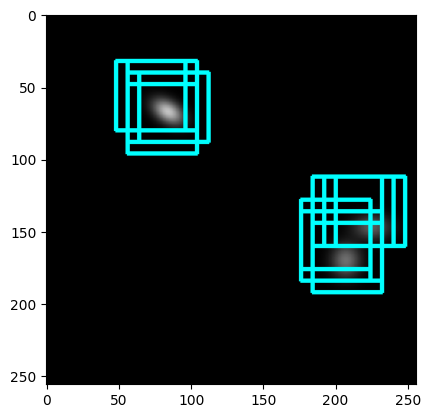

In [15]:
index = np.random.randint(low=0, high=VAL_COUNT)

img_visualization_one(img_arr_val[index], predictions_tf[index], threshold=0.03)
print(np.min(predictions_tf[index]), np.average(predictions_tf[index]), np.max(predictions_tf[index]))

# HLS4ML

In [19]:
# HLS4ML Config #
 
import hls4ml
from hls4ml.utils import config_from_keras_model
from pprint import pprint

config = config_from_keras_model(baby_yolo_tf, granularity='model', backend='Vitis')

config['Flows'] = ['vitis:fifo_depth_optimization']

hls4ml.model.optimizer.get_optimizer('vitis:fifo_depth_optimization').configure(profiling_fifo_depth=100_000)

# config['Model']['Strategy'] = 'Latency'
# config['Model']['PipelineStyle'] = 'pipeline'

# config["Model"]["ReuseFactor"] = 8
# for layer_cfg in config["LayerName"].values():
#     if "ReuseFactor" in layer_cfg:
#         layer_cfg["ReuseFactor"] = 8

# for layer_name, layer_cfg in config["LayerName"].items():
#     if layer_name.startswith("conv2d_") and layer_nusingame not in {'conv2d_4', 'conv2d_5', 'conv2d_4_relu', 'conv2d_5_sigmoid'}:
#         layer_cfg["Precision"] = "fixed<10,2>"
#     if layer_name.startswith("re_lu_"):
#         layer_cfg["Precision"] = "fixed<10,2>"
        
pprint(config)

Keras v2 handler used for layer b_1_1
Keras v2 handler used for layer b_1_2
Keras v2 handler used for layer b_2_1
Keras v2 handler used for layer b_2_2
Keras v2 handler used for layer b_3_1
Keras v2 handler used for layer b_3_2
{'Flows': ['vitis:fifo_depth_optimization'],
 'Model': {'BramFactor': 1000000000,
           'Precision': {'default': 'fixed<16,6>'},
           'ReuseFactor': 1,
           'Strategy': 'Latency',
           'TraceOutput': False}}


In [20]:
# Compile & Predict #
hls_model = hls4ml.converters.convert_from_keras_model(
    baby_yolo_tf,
    hls_config=config,
    output_dir='../folo_hls4ml',
    io_type='io_stream',
    backend='Vitis',
    part='xcku035-fbva676-2-e',
    project_name='folo'
)

# hls_model.compile()
 
# predictions_hls4ml = hls_model.predict(img_arr_val).reshape(VAL_COUNT, LABEL_Y, LABEL_X)

# print(f'[Validation Shape]: {img_arr_val.shape}')
# print(f'[Prediction Shape]: {predictions_hls4ml.shape}')

Keras v2 handler used for layer b_1_1
Keras v2 handler used for layer b_1_2
Keras v2 handler used for layer b_2_1
Keras v2 handler used for layer b_2_2
Keras v2 handler used for layer b_3_1
Keras v2 handler used for layer b_3_2

****** vitis-run v2025.2 (64-bit)
  **** SW Build 6295257 on 2025-11-13-01:29:13
  **** Start of session at: Thu Apr 23 21:35:09 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2025.2 6295257
Sourcing Tcl script '/home/pujan/Research/Rheed-FOLO/folo_hls4ml/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project folo_prj 
Resolution: For help on HLS 200-2182 see docs.amd.com/access/sources/dita/topic?Doc_Version=2025.2%20English&url=ug1448-hls-guidance&resourceid=200-2182.html
INFO: [HLS 200-10] Creating and opening solution '/home/pujan/Research/Rheed-FOLO/folo_hls4ml/folo_prj'.
INFO: [HLS 200-1510] Running: set_top folo 
INFO: [HLS 200-1510] Runn

In [21]:
hls_model.compile()
 
predictions_hls4ml = hls_model.predict(img_arr_val).reshape(VAL_COUNT, LABEL_Y, LABEL_X)

print(f'[Validation Shape]: {img_arr_val.shape}')
print(f'[Prediction Shape]: {predictions_hls4ml.shape}')

[Validation Shape]: (100, 256, 256, 1)
[Prediction Shape]: (100, 32, 32)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..200.0].


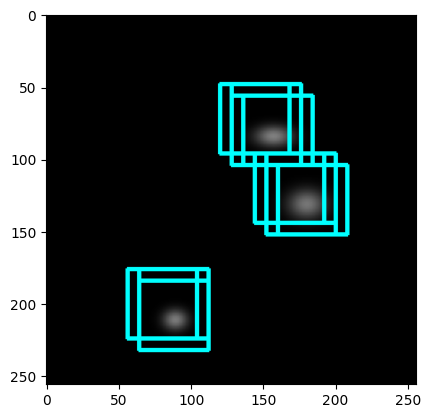

In [26]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)

img_visualization_one(img_arr_val[index], predictions_hls4ml[index], threshold=0.03)

In [ ]:
# Build Model #
# vitis_hls build_prj.tcl in SHELL

# hls_model.build(csim=False)

In [37]:
# View Report #
hls4ml.report.read_vivado_report('../folo_hls4ml')

Found 1 solution(s) in ../folo_hls4ml/folo_prj.
Reports for solution "solution1":

C simulation report not found.
Synthesis report not found.
Co-simulation report not found.
